In [1]:
import os
import sys
import time
from dataclasses import dataclass
from typing import Dict, List, Optional

import flax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
from flax import linen as nn
from tqdm import tqdm

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from optimisers.jax_fixed import (
    custom_sgd,
    custom_sgd_log,
    custom_sgd_rms,
)
from optimisers.jax_learnable_diag import (
    custom_sgd_learnable_diag,
    custom_sgd_log_learnable_diag,
)
from optimisers.jax_learnable_scalar import (
    custom_sgd_learnable_scalar,
    custom_sgd_log_learnable_scalar,
)

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)

import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

/Users/noah-everett/Documents/Research/Induced-Metric-Optimiser/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [2]:
# Configuration
tolerance = 1e-10
time_steps = 1000

# Configuration: Set to True for full experiment, False for demo
RUN_FULL_EXPERIMENT = True

# Optuna search controls
OPTUNA_SEED = 42
N_OPTUNA_TRIALS = 1000 if RUN_FULL_EXPERIMENT else 500
JOBS = 1

# OPTUNA_SAMPLER = optuna.samplers.TPESampler(seed=OPTUNA_SEED, multivariate=True)
# OPTUNA_SAMPLER = optuna.samplers.CmaEsSampler(seed=OPTUNA_SEED)
OPTUNA_SAMPLER = optuna.samplers.RandomSampler(seed=OPTUNA_SEED)
OPTUNA_PRUNER = (
    # optuna.pruners.SuccessiveHalvingPruner(min_resource=10, reduction_factor=4, min_early_stopping_rate=0)
    optuna.pruners.HyperbandPruner()
    # optuna.pruners.NopPruner()
)

# Test Functions

In [3]:
# Himmelblau function
@jax.jit
def himmelblau_function(params):
    x, y = params
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Ackley function
@jax.jit
def ackley_function(params):
    x, y = params
    a, b, c = 20.0, 0.2, 2 * jnp.pi
    term1 = -a * jnp.exp(-b * jnp.sqrt(0.5 * (x**2 + y**2)))
    term2 = -jnp.exp(0.5 * (jnp.cos(c * x) + jnp.cos(c * y)))
    return term1 + term2 + a + jnp.e

# Rastrigin function
@jax.jit
def rastrigin_function(params):
    x, y = params
    A = 10.0
    return A * 2 + (x**2 - A * jnp.cos(2 * jnp.pi * x)) + (y**2 - A * jnp.cos(2 * jnp.pi * y))

# Define the Beale function
@jax.jit
def beale_function(params):
    x, y = params
    term1 = (1.5 - x + x * y)**2
    term2 = (2.25 - x + x * y**2)**2
    term3 = (2.625 - x + x * y**3)**2
    return term1 + term2 + term3


# Define the Rosenbrock function with a=1, b=100
@jax.jit
def rosenbrock_function(params):
    x, y = params
    a = 1.0
    b = 100.0
    return (a - x)**2 + b * (y - x**2)**2

# Gradients
himmelblau_gradient = jax.jit(jax.grad(himmelblau_function))
ackley_gradient = jax.jit(jax.grad(ackley_function))
rastrigin_gradient = jax.jit(jax.grad(rastrigin_function))
beale_gradient = jax.jit(jax.grad(beale_function))
rosenbrock_gradient = jax.jit(jax.grad(rosenbrock_function))

# Test function registry
test_functions = {
    'beale': {
        'func': beale_function,
        'grad': beale_gradient,
        'global_min': jnp.array([3.0, 0.5]),
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-1, 4),
        'ylim': (-1, 1),
        'tolerance': 1e-7
    },
    'rosenbrock': {
        'func': rosenbrock_function,
        'grad': rosenbrock_gradient,
        'global_min': jnp.array([1.0, 1.0]),
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-0.5, 1.5),
        'ylim': (-0.5, 2.0),
        'tolerance': 1e-7
    },
    'himmelblau': {
        'func': himmelblau_function,
        'grad': himmelblau_gradient,
        'global_min': jnp.array([3.0, 2.0]),  # One of four global minima
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    },
    'ackley': {
        'func': ackley_function,
        'grad': ackley_gradient,
        'global_min': jnp.array([0.0, 0.0]),
        'initial': jnp.array([2.0, 2.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    },
    'rastrigin': {
        'func': rastrigin_function,
        'grad': rastrigin_gradient,
        'global_min': jnp.array([0.0, 0.0]),
        'initial': jnp.array([2.0, 2.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    }
}

print("Added test functions:")
for name, info in test_functions.items():
    print(f"  {name}: global minimum = {info['global_min']}")

Added test functions:
  beale: global minimum = [3.  0.5]
  rosenbrock: global minimum = [1. 1.]
  himmelblau: global minimum = [3. 2.]
  ackley: global minimum = [0. 0.]
  rastrigin: global minimum = [0. 0.]


# Optimisation Framework

In [4]:
@dataclass
class OptimisationResult:
    """Store results from optimisation run"""
    optimiser_name: str
    function_name: str
    converged: bool
    iterations: int
    final_value: float
    final_params: jnp.ndarray
    path: jnp.ndarray
    convergence_history: List[float]
    runtime_seconds: float
    config: Dict
    pruned: bool = False


def run_optimiser_on_function(
    optimiser_name: str,
    optimiser,
    function_info: Dict,
    config: Dict = None,
    max_iterations: int = 1000,
    trial: Optional["optuna.trial.Trial"] = None,
) -> OptimisationResult:
    """Run a single optimiser on a single function with timing and convergence tracking"""

    func = function_info['func']
    grad_func = function_info['grad']
    initial_params = function_info['initial']
    tolerance = function_info['tolerance']

    if config is None:
        config = {}

    # Initialise
    opt_state = optimiser.init(initial_params)
    params = initial_params.copy()
    path = [params.copy()]
    convergence_history = [float(func(params))]

    converged = False
    pruned = False
    iterations = 0
    runtime = 0.0

    for i in range(max_iterations):
        # Start timing after first iteration to exclude JIT compilation
        start_time = time.time()

        # Compute gradients
        grads = grad_func(params)

        # Update parameters - handle different optimizer signatures
        if optimiser_name in {
            'custom_sgd_log',
            'custom_sgd_log_learnable_diag',
            'custom_sgd_log_learnable_scalar'
        }:
            # Log variants expect loss as an additional argument
            current_loss = func(params)
            updates, opt_state = optimiser.update(grads, opt_state, current_loss, params)
        else:
            # All other optimizers follow standard optax signature
            updates, opt_state = optimiser.update(grads, opt_state, params)

        params = optax.apply_updates(params, updates)
        runtime += max(time.time() - start_time, 0.0)

        path.append(params.copy())

        # Check convergence
        current_value = func(params)
        convergence_history.append(float(current_value))

        iterations = i + 1
        if current_value <= tolerance:
            converged = True
            break

        if trial is not None:
            trial.report(float(current_value), step=i)
            if trial.should_prune():
                pruned = True
                break

    assert iterations > 0, "Optimiser did not perform any iterations."
    assert runtime > 0.0, "Runtime measurement failed."

    if not converged and not pruned and iterations < max_iterations:
        iterations = max_iterations

    return OptimisationResult(
        optimiser_name=optimiser_name,
        function_name=function_info.get('name', 'unknown'),
        converged=converged,
        iterations=iterations,
        final_value=float(func(params)),
        final_params=params,
        path=jnp.array(path),
        convergence_history=convergence_history,
        runtime_seconds=runtime,
        config=config,
        pruned=pruned
    )

# Run Comprehensive Experiments

In [5]:
# Run Optuna-driven optimisation experiments

optimiser_factories = {
    'adam': lambda **kwargs: optax.adam(**kwargs),
    'sgd': lambda **kwargs: optax.sgd(**kwargs),
    'custom_sgd': lambda **kwargs: custom_sgd(**kwargs),
    'custom_sgd_log': lambda **kwargs: custom_sgd_log(**kwargs),
    'custom_sgd_rms': lambda **kwargs: custom_sgd_rms(**kwargs),
    'muon': lambda **kwargs: optax.contrib.muon(**kwargs),
    'custom_sgd_learnable_diag': lambda **kwargs: custom_sgd_learnable_diag(**kwargs),
    'custom_sgd_log_learnable_diag': lambda **kwargs: custom_sgd_log_learnable_diag(**kwargs),
    'custom_sgd_learnable_scalar': lambda **kwargs: custom_sgd_learnable_scalar(**kwargs),
    'custom_sgd_log_learnable_scalar': lambda **kwargs: custom_sgd_log_learnable_scalar(**kwargs)
}


def suggest_hyperparameters(trial: optuna.Trial, optimiser_name: str) -> Dict:
    prefix = f"{optimiser_name}_"

    if optimiser_name == 'adam':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'b1': trial.suggest_float(prefix + 'b1', 0.0, 0.99),
            'b2': trial.suggest_float(prefix + 'b2', 0.8, 0.9999),
            'eps': trial.suggest_float(prefix + 'eps', 1e-10, 1e-6, log=True)
        }
    if optimiser_name == 'sgd':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'momentum': trial.suggest_float(prefix + 'momentum', 0.0, 0.99)
        }
    if optimiser_name == 'custom_sgd':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'momentum': trial.suggest_float(prefix + 'momentum', 0.0, 0.99),
            'xi': trial.suggest_float(prefix + 'xi', 1e-3, 1e1, log=True),
            'beta': 0.0
        }
    if optimiser_name == 'custom_sgd_log':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'momentum': trial.suggest_float(prefix + 'momentum', 0.0, 0.99),
            'xi': trial.suggest_float(prefix + 'xi', 1e-3, 1e1, log=True),
            'beta': 0.0
        }
    if optimiser_name == 'custom_sgd_rms':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'momentum': trial.suggest_float(prefix + 'momentum', 0.0, 0.99),
            'xi': trial.suggest_float(prefix + 'xi', 1e-3, 1e1, log=True),
            'beta': 0.0,
            'beta_rms': trial.suggest_float(prefix + 'beta_rms', 0.8, 0.9999),
            'eps': trial.suggest_float(prefix + 'eps', 1e-10, 1e-6, log=True)
        }
    if optimiser_name == 'muon':
        return {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'adam_b1': trial.suggest_float(prefix + 'adam_b1', 0.0, 0.99),
            'adam_b2': trial.suggest_float(prefix + 'adam_b2', 0.8, 0.9999),
            'eps': trial.suggest_float(prefix + 'eps', 1e-10, 1e-6, log=True),
            'beta': trial.suggest_float(prefix + 'beta', 0.5, 0.999)
        }
    if optimiser_name in {
        'custom_sgd_learnable_diag',
        'custom_sgd_log_learnable_diag',
        'custom_sgd_learnable_scalar',
        'custom_sgd_log_learnable_scalar'
    }:
        base_config = {
            'learning_rate': trial.suggest_float(prefix + 'learning_rate', 1e-6, 1e1, log=True),
            'momentum': trial.suggest_float(prefix + 'momentum', 0.0, 0.99),
            'xi': trial.suggest_float(prefix + 'xi', 1e-3, 1e1, log=True),
            'beta': trial.suggest_float(prefix + 'beta', 0.5, 0.99),
            'metric_lr': trial.suggest_float(prefix + 'metric_lr', 1e-5, 1.0, log=True),
            'metric_reg': trial.suggest_float(prefix + 'metric_reg', 1e-6, 1e-2, log=True),
            'metric_clip': trial.suggest_float(prefix + 'metric_clip', 1.0, 5.0)
        }
        return base_config

    raise ValueError(f"Unknown optimiser: {optimiser_name}")


def compute_objective_score(result: OptimisationResult) -> float:
    """Scalarised metric for Optuna (lower is better)."""
    penalty = 0.0 if result.converged else 100.0
    prune_penalty = 50.0 if result.pruned else 0.0
    iteration_term = 0.01 * result.iterations
    runtime_term = result.runtime_seconds
    return float(result.final_value) + penalty + prune_penalty + iteration_term + runtime_term


def run_experiments() -> List[OptimisationResult]:
    """Run optimisation experiments powered by Optuna."""
    total_trials = len(test_functions) * len(optimiser_factories) * N_OPTUNA_TRIALS
    print("OPTUNA SEARCH CONFIGURATION")
    print("=" * 50)
    print(f"Mode: {'FULL EXPERIMENT' if RUN_FULL_EXPERIMENT else 'DEMO EXPERIMENT'}")
    print(f"Trials per optimiser/function: {N_OPTUNA_TRIALS}")
    print(f"Total objective evaluations (max): {total_trials}")
    print("=" * 50)

    results: List[OptimisationResult] = []

    with tqdm(total=total_trials, desc="Optuna trials") as pbar:
        for func_name, func_info in test_functions.items():
            func_info_with_name = {**func_info, 'name': func_name}

            for optimiser_name, factory in optimiser_factories.items():
                study = optuna.create_study(
                    direction='minimize',
                    sampler=OPTUNA_SAMPLER,
                    pruner=OPTUNA_PRUNER,
                    study_name=f"{optimiser_name}_{func_name}"
                )

                def objective(trial: optuna.Trial) -> float:
                    config = suggest_hyperparameters(trial, optimiser_name)
                    optimiser = factory(**config)

                    result = run_optimiser_on_function(
                        optimiser_name,
                        optimiser,
                        func_info_with_name,
                        config=config,
                        max_iterations=time_steps,
                        trial=trial
                    )

                    results.append(result)
                    trial.set_user_attr('converged', result.converged)
                    trial.set_user_attr('iterations', result.iterations)
                    trial.set_user_attr('final_value', result.final_value)
                    trial.set_user_attr('pruned', result.pruned)
                    trial.set_user_attr('config', config)

                    score = compute_objective_score(result)
                    pbar.update(1)

                    if result.pruned:
                        raise optuna.TrialPruned()

                    return score

                try:
                    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False, n_jobs=JOBS)
                except optuna.exceptions.TrialPruned:
                    # Individual trials raise TrialPruned, but the study continues.
                    pass
                except Exception as exc:
                    print(f"Error during {optimiser_name} on {func_name}: {exc}")

                if len(study.trials) > 0 and study.best_trial is not None:
                    best = study.best_trial
                    # print(
                    #     f"Best {optimiser_name:30s} on {func_name:12s} | "
                    #     f"value={best.value:.3e} | converged={best.user_attrs.get('converged')} | "
                    #     f"iterations={best.user_attrs.get('iterations')}"
                    # )

    return results


# Run experiments
results = run_experiments()

print(f"\nCompleted {len(results)} optimisation runs!")
print(f"Successful convergences: {sum(1 for r in results if r.converged)}")
print(f"Failed convergences: {sum(1 for r in results if not r.converged)}")
print(f"Pruned trials: {sum(1 for r in results if r.pruned)}")

if RUN_FULL_EXPERIMENT:
    print("✅ Full Optuna experiment completed!")
else:
    print("✅ Demo Optuna experiment completed!")
    print("💡 To run full experiment: Set RUN_FULL_EXPERIMENT = True")

OPTUNA SEARCH CONFIGURATION
Mode: FULL EXPERIMENT
Trials per optimiser/function: 1000
Total objective evaluations (max): 50000


Optuna trials: 100%|██████████| 50000/50000 [32:48<00:00, 25.40it/s]  


Completed 50000 optimisation runs!
Successful convergences: 602
Failed convergences: 49398
Pruned trials: 48231
✅ Full Optuna experiment completed!


# Results Analysis and Visualisation

In [6]:
def analyse_results(results: List[OptimisationResult]) -> pd.DataFrame:
    """Convert results to DataFrame for analysis"""
    data = []
    for result in results:
        data.append({
            'optimiser': result.optimiser_name,
            'function': result.function_name,
            'converged': result.converged,
            'iterations': result.iterations,
            'final_value': result.final_value,
            'runtime_seconds': result.runtime_seconds,
            'runtime_ms': result.runtime_seconds * 1000,
            'config': result.config,
            'convergence_history': list(result.convergence_history),
            'result_obj': result
        })
    return pd.DataFrame(data)

def get_best_results(df: pd.DataFrame) -> pd.DataFrame:
    """Get best result for each optimiser-function combination"""
    best_results = []
    
    for (optimiser, function), group in df.groupby(['optimiser', 'function']):
        # First priority: converged runs (by iterations)
        converged = group[group['converged'] == True]
        if len(converged) > 0:
            best = converged.loc[converged['iterations'].idxmin()]
        else:
            # Second priority: non-converged runs (by final value)
            best = group.loc[group['final_value'].idxmin()]
        
        best_results.append(best)
    
    return pd.DataFrame(best_results)

# Analyse results
df = analyse_results(results)
best_df = get_best_results(df)

print("Results Summary:")
print(f"Total experiments: {len(df)}")
print(f"Unique optimiser-function combinations: {len(best_df)}")
print(f"Overall convergence rate: {df['converged'].mean():.2%}")

print("\nConvergence by optimiser:")
convergence_by_opt = df.groupby('optimiser')['converged'].agg(['count', 'sum', 'mean'])
convergence_by_opt.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(convergence_by_opt)

print("\nConvergence by function:")
convergence_by_func = df.groupby('function')['converged'].agg(['count', 'sum', 'mean'])
convergence_by_func.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(convergence_by_func)

Results Summary:
Total experiments: 50000
Unique optimiser-function combinations: 50
Overall convergence rate: 1.20%

Convergence by optimiser:
                                 total_runs  converged_runs  convergence_rate
optimiser                                                                    
adam                                   5000              56            0.0112
custom_sgd                             5000              36            0.0072
custom_sgd_learnable_diag              5000              25            0.0050
custom_sgd_learnable_scalar            5000              37            0.0074
custom_sgd_log                         5000             100            0.0200
custom_sgd_log_learnable_diag          5000              75            0.0150
custom_sgd_log_learnable_scalar        5000             112            0.0224
custom_sgd_rms                         5000              27            0.0054
muon                                   5000              59            0.011

In [7]:
optimiser_order = [
    'sgd',
    'adam',
    'muon',
    'custom_sgd',
    'custom_sgd_log',
    'custom_sgd_rms',
    'custom_sgd_learnable_scalar',
    'custom_sgd_log_learnable_scalar',
    'custom_sgd_learnable_diag',
    'custom_sgd_log_learnable_diag'
]
best_df['optimiser'] = pd.Categorical(best_df['optimiser'], categories=optimiser_order, ordered=True)
best_df = best_df.sort_values(by=['function', 'optimiser']).reset_index(drop=True)
best_df

,optimiser,function,converged,iterations,final_value,runtime_seconds,runtime_ms,config,convergence_history,result_obj
0,sgd,ackley,False,1000,3.152568e+00,0.071485,71.485043,"{'learning_rate': 0.1864355698493002, 'momentu...","[6.593599079287216, 7.624322494722373, 6.64599...","OptimisationResult(optimiser_name='sgd', funct..."
1,adam,ackley,False,1000,3.931429e-02,0.303065,303.064585,"{'learning_rate': 0.732779357226718, 'b1': 0.8...","[6.593599079287216, 6.298183346289893, 4.51854...","OptimisationResult(optimiser_name='adam', func..."
2,muon,ackley,False,1000,5.770938e-02,0.669307,669.306755,"{'learning_rate': 0.46848652409925146, 'adam_b...","[6.593599079287216, 6.574246024849405, 4.55799...","OptimisationResult(optimiser_name='muon', func..."
3,custom_sgd,ackley,False,1000,1.335088e-01,0.086267,86.267471,"{'learning_rate': 2.3811062371478373, 'momentu...","[6.593599079287216, 7.782214902410772, 4.10160...",OptimisationResult(optimiser_name='custom_sgd'...
4,custom_sgd_log,ackley,True,12,1.734269e-07,0.030548,30.547857,"{'learning_rate': 5.750135134454554, 'momentum...","[6.593599079287216, 6.709795203582189, 3.59602...",OptimisationResult(optimiser_name='custom_sgd_...
5,custom_sgd_rms,ackley,False,1000,2.626182e-02,0.093680,93.679667,"{'learning_rate': 0.4819271781429639, 'momentu...","[6.593599079287216, 7.588847634576274, 3.83151...",OptimisationResult(optimiser_name='custom_sgd_...
6,custom_sgd_learnable_scalar,ackley,False,1000,3.949233e-02,0.096492,96.492290,"{'learning_rate': 6.822135381233735, 'momentum...","[6.593599079287216, 7.005022806783067, 3.58717...",OptimisationResult(optimiser_name='custom_sgd_...
7,custom_sgd_log_learnable_scalar,ackley,True,10,3.174682e-07,0.041903,41.902542,"{'learning_rate': 4.214734650104108, 'momentum...","[6.593599079287216, 6.487732484381073, 0.03832...",OptimisationResult(optimiser_name='custom_sgd_...
8,custom_sgd_learnable_diag,ackley,False,1000,7.077632e-02,0.095479,95.479250,"{'learning_rate': 0.434773784034966, 'momentum...","[6.593599079287216, 7.782522494855989, 7.49111...",OptimisationResult(optimiser_name='custom_sgd_...
9,custom_sgd_log_learnable_diag,ackley,True,11,2.912306e-07,0.044154,44.154406,"{'learning_rate': 6.42789251575666, 'momentum'...","[6.593599079287216, 4.369148374889292, 4.48088...",OptimisationResult(optimiser_name='custom_sgd_...


Optimiser: sgd, Convergence Rate: 60.00%, Avg Iterations: 120.7, Avg Runtime: 9.2 ms, Performance Score: 412.16
Optimiser: adam, Convergence Rate: 40.00%, Avg Iterations: 54.0, Avg Runtime: 16.4 ms, Performance Score: 605.56
Optimiser: muon, Convergence Rate: 40.00%, Avg Iterations: 72.0, Avg Runtime: 50.2 ms, Performance Score: 607.70
Optimiser: custom_sgd, Convergence Rate: 60.00%, Avg Iterations: 83.3, Avg Runtime: 35.4 ms, Performance Score: 408.69
Optimiser: custom_sgd_log, Convergence Rate: 80.00%, Avg Iterations: 21.8, Avg Runtime: 33.3 ms, Performance Score: 202.51
Optimiser: custom_sgd_rms, Convergence Rate: 60.00%, Avg Iterations: 360.3, Avg Runtime: 58.9 ms, Performance Score: 436.62
Optimiser: custom_sgd_learnable_scalar, Convergence Rate: 80.00%, Avg Iterations: 159.2, Avg Runtime: 45.9 ms, Performance Score: 216.38
Optimiser: custom_sgd_log_learnable_scalar, Convergence Rate: 100.00%, Avg Iterations: 62.2, Avg Runtime: 42.3 ms, Performance Score: 6.64
Optimiser: custom_sg

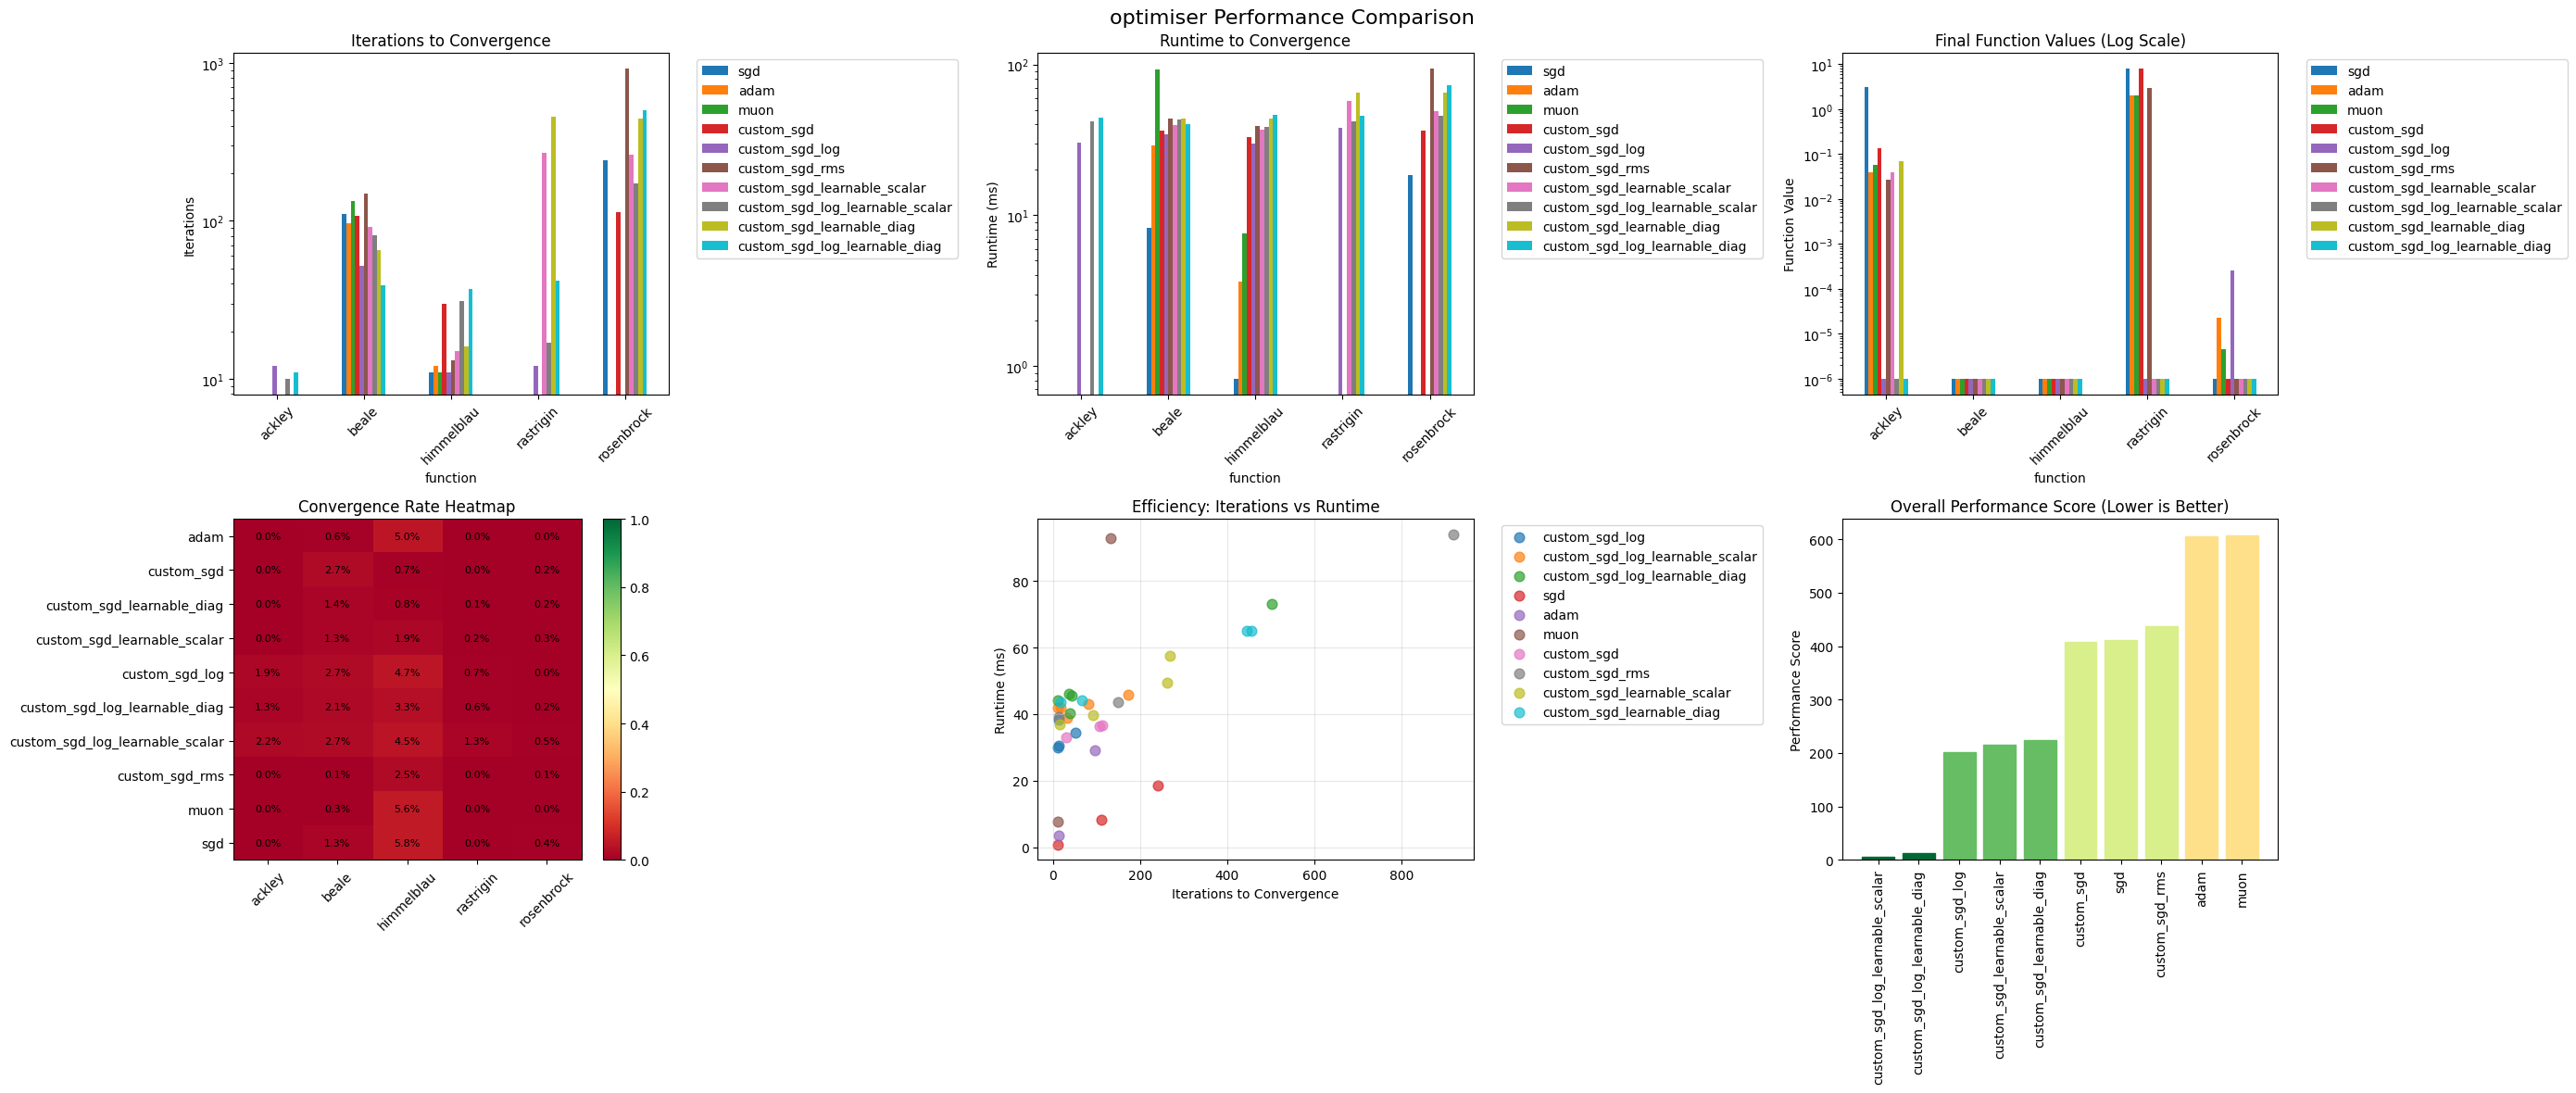

In [8]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(28, 12))
fig.suptitle('optimiser Performance Comparison', fontsize=16)

epsilon = 1e-6

# 1. Iterations to convergence (converged runs only)
ax = axes[0, 0]
converged_best = best_df[best_df['converged'] == True]
if len(converged_best) > 0:
    pivot_iterations = converged_best.pivot(index='function', columns='optimiser', values='iterations')
    pivot_iterations = pivot_iterations.clip(lower=epsilon)
    pivot_iterations.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Iterations to Convergence')
    ax.set_ylabel('Iterations')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_yscale('log')

# 2. Runtime comparison
ax = axes[0, 1]
converged_best = best_df[best_df['converged'] == True]
if len(converged_best) > 0:
    pivot_runtime = converged_best.pivot(index='function', columns='optimiser', values='runtime_ms')
    pivot_runtime = pivot_runtime.clip(lower=epsilon)
    pivot_runtime.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Runtime to Convergence')
    ax.set_ylabel('Runtime (ms)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_yscale('log')

# 3. Final values (all runs)
ax = axes[0, 2]
pivot_values = best_df.pivot(index='function', columns='optimiser', values='final_value')
pivot_values = pivot_values.clip(lower=epsilon)
pivot_values.plot(kind='bar', ax=ax, rot=45, logy=True)
ax.set_title('Final Function Values (Log Scale)')
ax.set_ylabel('Function Value')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Convergence rate heatmap
ax = axes[1, 0]
convergence_matrix = df.groupby(['optimiser', 'function'])['converged'].mean().unstack()
im = ax.imshow(convergence_matrix.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(convergence_matrix.columns)))
ax.set_xticklabels(convergence_matrix.columns, rotation=45)
ax.set_yticks(range(len(convergence_matrix.index)))
ax.set_yticklabels(convergence_matrix.index)
ax.set_title('Convergence Rate Heatmap')
plt.colorbar(im, ax=ax)

# Add text annotations
for i in range(len(convergence_matrix.index)):
    for j in range(len(convergence_matrix.columns)):
        text = ax.text(j, i, f'{convergence_matrix.iloc[i, j]:.1%}',
                      ha="center", va="center", color="black", fontsize=8)

# 5. Efficiency scatter plot (iterations vs runtime for converged runs)
ax = axes[1, 1]
for optimiser in converged_best['optimiser'].unique():
    opt_data = converged_best[converged_best['optimiser'] == optimiser]
    ax.scatter(opt_data['iterations'], opt_data['runtime_ms'].clip(lower=epsilon),
              label=optimiser, alpha=0.7, s=60)

ax.set_xlabel('Iterations to Convergence')
ax.set_ylabel('Runtime (ms)')
ax.set_title('Efficiency: Iterations vs Runtime')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 6. Overall performance ranking
ax = axes[1, 2]
# Calculate performance score (lower is better)
performance_scores = []
for optimiser in best_df['optimiser'].unique():
    opt_data = best_df[best_df['optimiser'] == optimiser]
    converged_rate = opt_data['converged'].mean()
    avg_iterations = opt_data[opt_data['converged']]['iterations'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    avg_runtime = opt_data[opt_data['converged']]['runtime_ms'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    
    # Performance score combines convergence rate (higher is better) and speed (lower is better)
    score = (1 - converged_rate) * 1000 + avg_iterations * 0.1 + avg_runtime * 0.01
    performance_scores.append({'optimiser': optimiser, 'score': score, 'convergence_rate': converged_rate})

    print(f"Optimiser: {optimiser}, Convergence Rate: {converged_rate:.2%}, Avg Iterations: {avg_iterations:.1f}, Avg Runtime: {avg_runtime:.1f} ms, Performance Score: {score:.2f}")

performance_df = pd.DataFrame(performance_scores).sort_values('score')
bars = ax.bar(performance_df['optimiser'], performance_df['score'])
ax.set_title('Overall Performance Score (Lower is Better)')
ax.set_ylabel('Performance Score')
ax.tick_params(axis='x', rotation=90)

# Color bars by convergence rate
colors = plt.cm.RdYlGn(performance_df['convergence_rate'])
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.show()

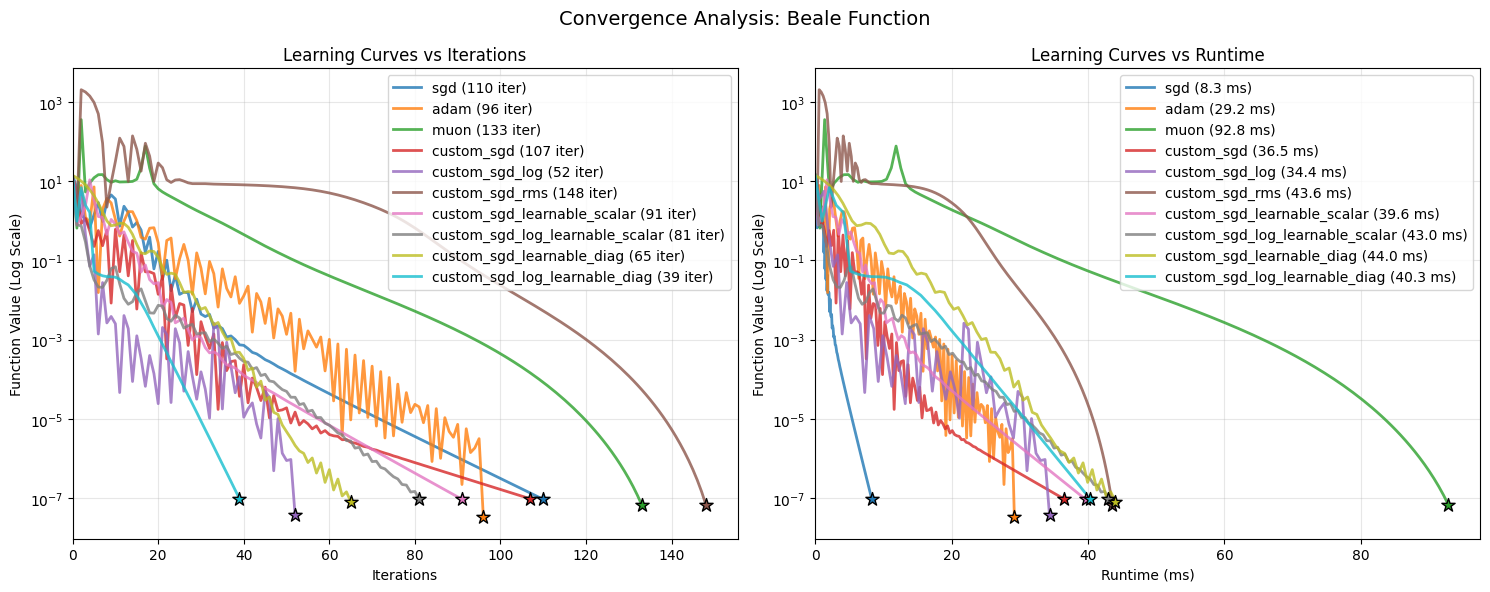


Beale Function Summary:
--------------------------------------------------
sgd                            : ✓ Converged  |  110 iter |    8.3 ms | Final: 9.19e-08
adam                           : ✓ Converged  |   96 iter |   29.2 ms | Final: 3.22e-08
muon                           : ✓ Converged  |  133 iter |   92.8 ms | Final: 6.73e-08
custom_sgd                     : ✓ Converged  |  107 iter |   36.5 ms | Final: 9.46e-08
custom_sgd_log                 : ✓ Converged  |   52 iter |   34.4 ms | Final: 3.62e-08
custom_sgd_rms                 : ✓ Converged  |  148 iter |   43.6 ms | Final: 6.79e-08
custom_sgd_learnable_scalar    : ✓ Converged  |   91 iter |   39.6 ms | Final: 9.23e-08
custom_sgd_log_learnable_scalar: ✓ Converged  |   81 iter |   43.0 ms | Final: 9.26e-08
custom_sgd_learnable_diag      : ✓ Converged  |   65 iter |   44.0 ms | Final: 8.03e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |   39 iter |   40.3 ms | Final: 9.48e-08


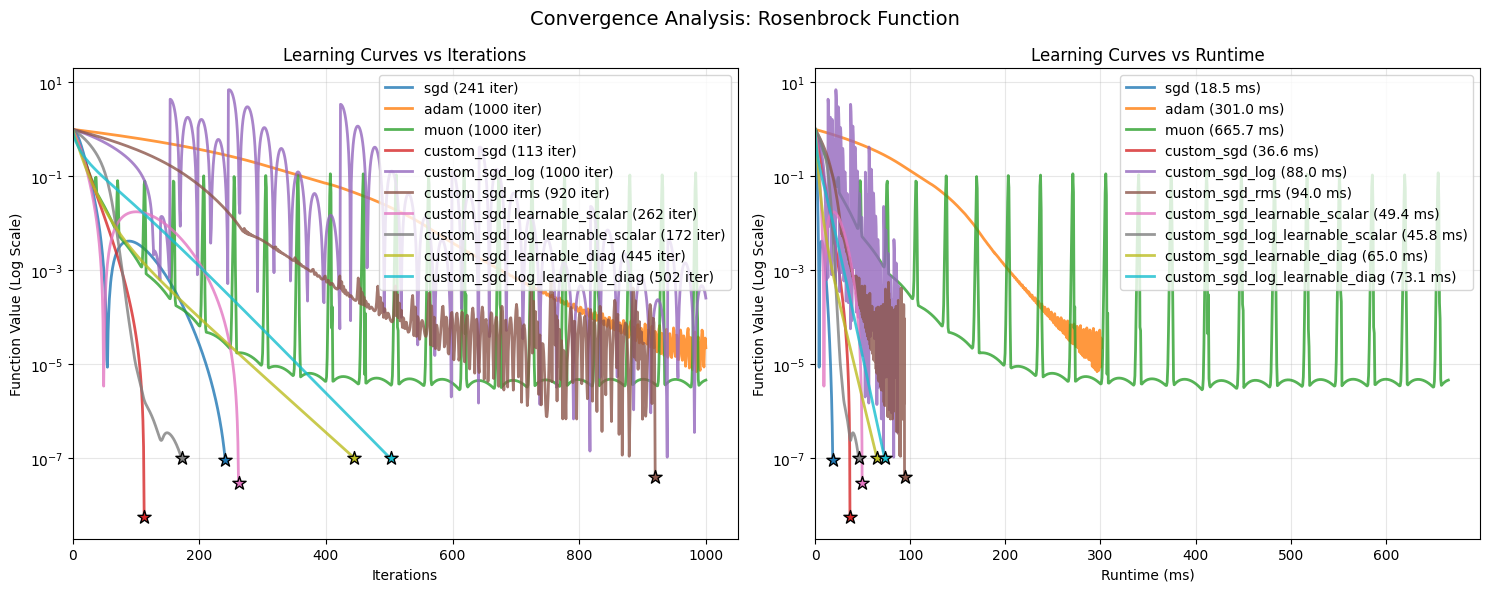


Rosenbrock Function Summary:
--------------------------------------------------
sgd                            : ✓ Converged  |  241 iter |   18.5 ms | Final: 9.00e-08
adam                           : ✗ Failed     | 1000 iter |  301.0 ms | Final: 2.23e-05
muon                           : ✗ Failed     | 1000 iter |  665.7 ms | Final: 4.54e-06
custom_sgd                     : ✓ Converged  |  113 iter |   36.6 ms | Final: 5.41e-09
custom_sgd_log                 : ✗ Failed     | 1000 iter |   88.0 ms | Final: 2.54e-04
custom_sgd_rms                 : ✓ Converged  |  920 iter |   94.0 ms | Final: 3.98e-08
custom_sgd_learnable_scalar    : ✓ Converged  |  262 iter |   49.4 ms | Final: 2.86e-08
custom_sgd_log_learnable_scalar: ✓ Converged  |  172 iter |   45.8 ms | Final: 9.81e-08
custom_sgd_learnable_diag      : ✓ Converged  |  445 iter |   65.0 ms | Final: 9.90e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |  502 iter |   73.1 ms | Final: 9.71e-08


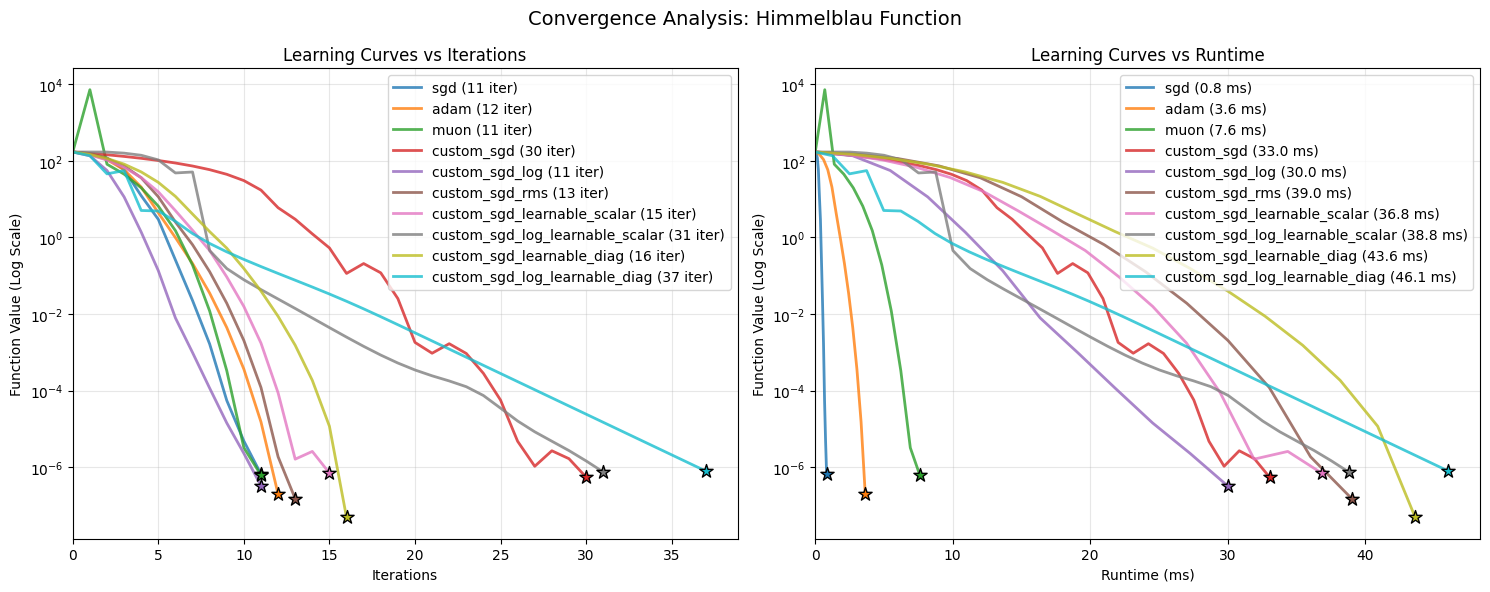


Himmelblau Function Summary:
--------------------------------------------------
sgd                            : ✓ Converged  |   11 iter |    0.8 ms | Final: 6.65e-07
adam                           : ✓ Converged  |   12 iter |    3.6 ms | Final: 1.99e-07
muon                           : ✓ Converged  |   11 iter |    7.6 ms | Final: 6.26e-07
custom_sgd                     : ✓ Converged  |   30 iter |   33.0 ms | Final: 5.55e-07
custom_sgd_log                 : ✓ Converged  |   11 iter |   30.0 ms | Final: 3.28e-07
custom_sgd_rms                 : ✓ Converged  |   13 iter |   39.0 ms | Final: 1.52e-07
custom_sgd_learnable_scalar    : ✓ Converged  |   15 iter |   36.8 ms | Final: 7.09e-07
custom_sgd_log_learnable_scalar: ✓ Converged  |   31 iter |   38.8 ms | Final: 7.56e-07
custom_sgd_learnable_diag      : ✓ Converged  |   16 iter |   43.6 ms | Final: 4.95e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |   37 iter |   46.1 ms | Final: 7.97e-07


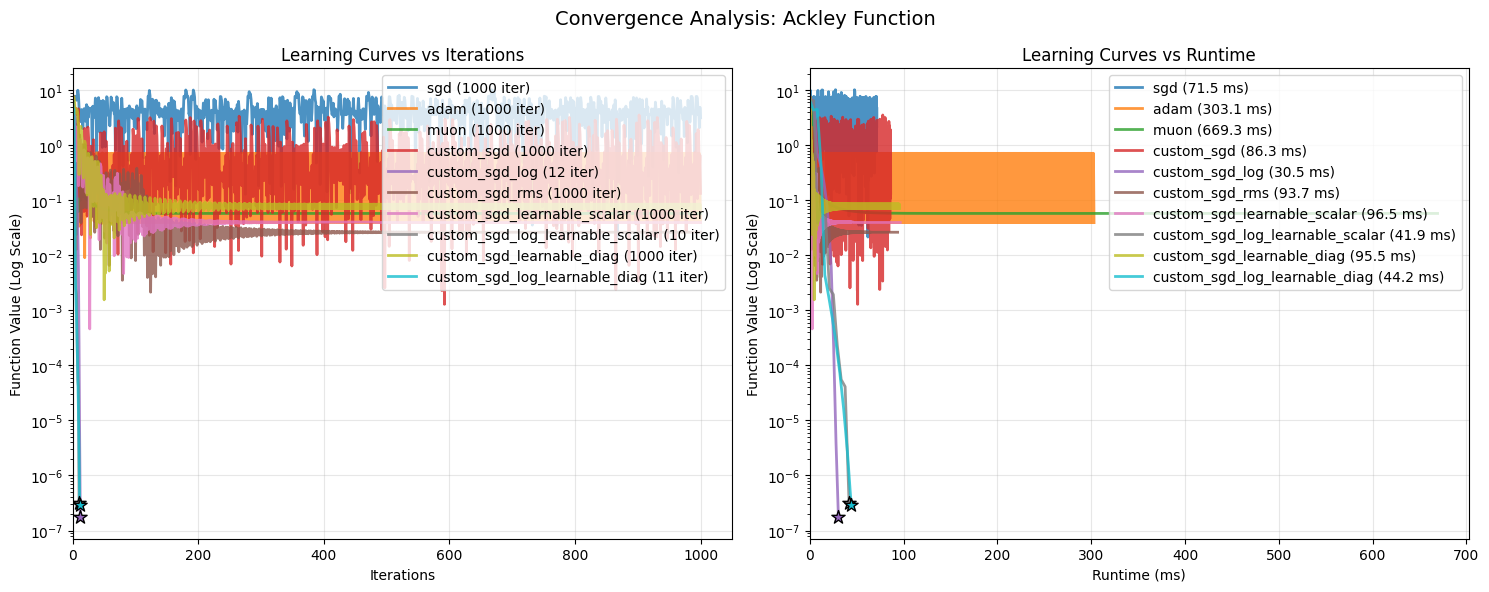


Ackley Function Summary:
--------------------------------------------------
sgd                            : ✗ Failed     | 1000 iter |   71.5 ms | Final: 3.15e+00
adam                           : ✗ Failed     | 1000 iter |  303.1 ms | Final: 3.93e-02
muon                           : ✗ Failed     | 1000 iter |  669.3 ms | Final: 5.77e-02
custom_sgd                     : ✗ Failed     | 1000 iter |   86.3 ms | Final: 1.34e-01
custom_sgd_log                 : ✓ Converged  |   12 iter |   30.5 ms | Final: 1.73e-07
custom_sgd_rms                 : ✗ Failed     | 1000 iter |   93.7 ms | Final: 2.63e-02
custom_sgd_learnable_scalar    : ✗ Failed     | 1000 iter |   96.5 ms | Final: 3.95e-02
custom_sgd_log_learnable_scalar: ✓ Converged  |   10 iter |   41.9 ms | Final: 3.17e-07
custom_sgd_learnable_diag      : ✗ Failed     | 1000 iter |   95.5 ms | Final: 7.08e-02
custom_sgd_log_learnable_diag  : ✓ Converged  |   11 iter |   44.2 ms | Final: 2.91e-07


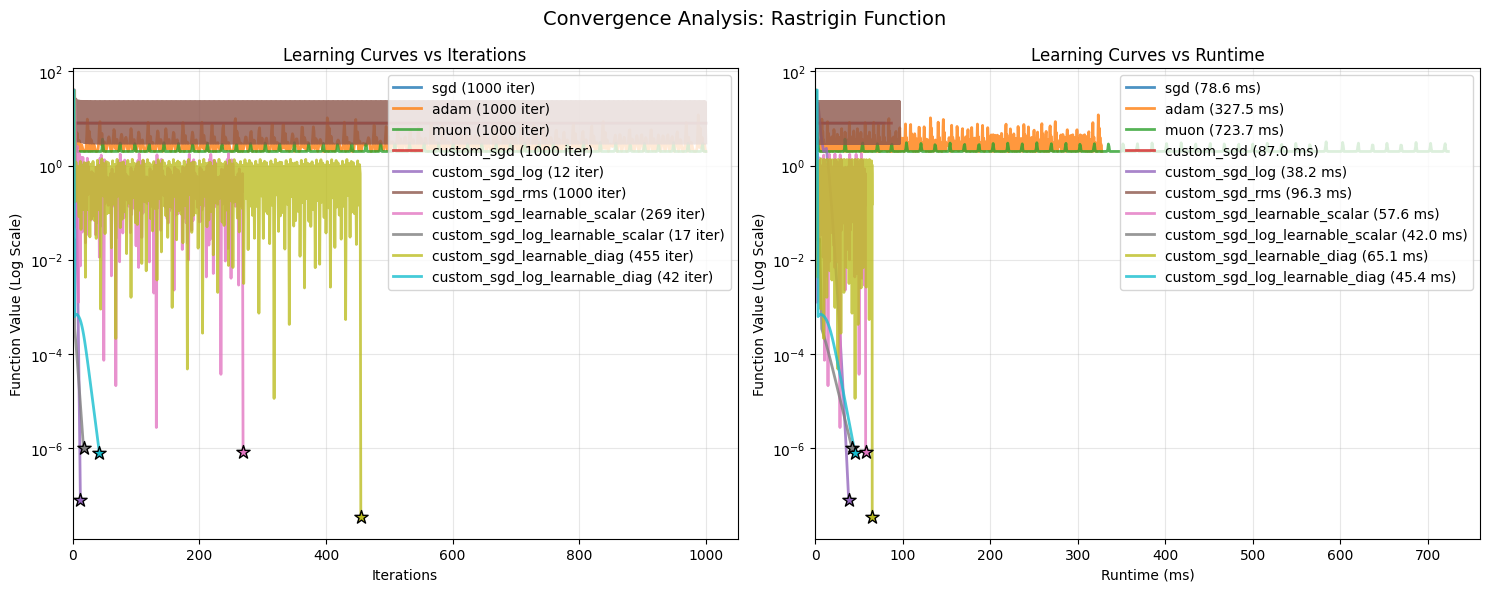


Rastrigin Function Summary:
--------------------------------------------------
sgd                            : ✗ Failed     | 1000 iter |   78.6 ms | Final: 7.96e+00
adam                           : ✗ Failed     | 1000 iter |  327.5 ms | Final: 1.99e+00
muon                           : ✗ Failed     | 1000 iter |  723.7 ms | Final: 1.99e+00
custom_sgd                     : ✗ Failed     | 1000 iter |   87.0 ms | Final: 7.96e+00
custom_sgd_log                 : ✓ Converged  |   12 iter |   38.2 ms | Final: 7.92e-08
custom_sgd_rms                 : ✗ Failed     | 1000 iter |   96.3 ms | Final: 3.01e+00
custom_sgd_learnable_scalar    : ✓ Converged  |  269 iter |   57.6 ms | Final: 8.19e-07
custom_sgd_log_learnable_scalar: ✓ Converged  |   17 iter |   42.0 ms | Final: 9.83e-07
custom_sgd_learnable_diag      : ✓ Converged  |  455 iter |   65.1 ms | Final: 3.35e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |   42 iter |   45.4 ms | Final: 7.93e-07


In [9]:
# Convergence analysis with learning curves

def plot_convergence_curves(best_df: pd.DataFrame, function_name: str):
    """Plot convergence curves for each optimiser's best config on a function."""
    function_best = best_df[best_df['function'] == function_name].copy()
    if function_best.empty:
        print(f"No best results available for {function_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Convergence Analysis: {function_name.title()} Function', fontsize=14)

    colours = plt.cm.tab10(np.linspace(0, 1, len(function_best)))

    # Plot 1: Learning curves vs iterations (log scale)
    ax1 = axes[0]
    for (_, row), colour in zip(function_best.iterrows(), colours):
        history = row.get('convergence_history', [])
        if history is None or len(history) == 0:
            continue

        iterations_axis = range(len(history))
        optimiser = row['optimiser']
        iteration_count = int(row['iterations'])

        ax1.semilogy(iterations_axis, history, label=f"{optimiser} ({iteration_count} iter)",
                     color=colour, linewidth=2, alpha=0.8)

        if row['converged']:
            conv_idx = min(iteration_count, len(history) - 1)
            conv_value = history[conv_idx]
            ax1.scatter(conv_idx, conv_value, color=colour, s=100, marker='*',
                        edgecolor='black', linewidth=1, zorder=10)

    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Function Value (Log Scale)')
    ax1.set_title('Learning Curves vs Iterations')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(left=0)
    # ax1.set_ylim(bottom=1e-8)
    
    # Plot 2: Learning curves vs runtime (log scale)
    ax2 = axes[1]
    for (_, row), colour in zip(function_best.iterrows(), colours):
        history = row.get('convergence_history', [])
        if history is None or len(history) == 0:
            continue

        runtime_ms = float(row['runtime_ms'])
        time_points = np.linspace(0, runtime_ms, len(history))
        optimiser = row['optimiser']

        ax2.semilogy(time_points, history,
                     label=f"{optimiser} ({runtime_ms:.1f} ms)",
                     color=colour, linewidth=2, alpha=0.8)

        if row['converged']:
            conv_idx = min(int(row['iterations']), len(history) - 1)
            conv_value = history[conv_idx]
            ax2.scatter(time_points[conv_idx], conv_value, color=colour, s=100, marker='*',
                        edgecolor='black', linewidth=1, zorder=10)

    ax2.set_xlabel('Runtime (ms)')
    ax2.set_ylabel('Function Value (Log Scale)')
    ax2.set_title('Learning Curves vs Runtime')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    # ax2.set_ylim(bottom=1e-8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{function_name.title()} Function Summary:")
    print("-" * 50)
    for optimiser, result in function_best.set_index('optimiser')['result_obj'].items():
        status = "✓ Converged" if result.converged else "✗ Failed"
        print(f"{optimiser:31s}: {status:12s} | {result.iterations:4d} iter | "
              f"{result.runtime_seconds*1000:6.1f} ms | Final: {result.final_value:.2e}")

# Plot convergence curves for each function
for function_name in test_functions.keys():
    plot_convergence_curves(best_df, function_name)


In [10]:
#
print("=" * 80)
print("COMPREHENSIVE OPTIMISATION EXPERIMENT RESULTS")
print("=" * 80)

# Create summary table
summary_data = []
for function_name in test_functions.keys():
    function_results = [r for r in results if r.function_name == function_name]
    best_results_by_optimiser = {}
    
    for result in function_results:
        optimiser = result.optimiser_name
        if optimiser not in best_results_by_optimiser:
            best_results_by_optimiser[optimiser] = result
        else:
            current_best = best_results_by_optimiser[optimiser]
            if (result.converged and not current_best.converged) or \
               (result.converged == current_best.converged and 
                (result.iterations < current_best.iterations if result.converged else 
                 result.final_value < current_best.final_value)):
                best_results_by_optimiser[optimiser] = result
    
    for optimiser, result in best_results_by_optimiser.items():
        summary_data.append({
            'Function': function_name,
            'optimiser': optimiser,
            'Converged': result.converged,
            'Iterations': result.iterations,
            'Runtime (ms)': result.runtime_seconds * 1000,
            'Time per Iteration (ms)': (result.runtime_seconds * 1000) / result.iterations if result.iterations > 0 else 0,
            'Final Value': result.final_value,
            'Efficiency': result.iterations / (result.runtime_seconds * 1000) if result.runtime_seconds > 0 else 0
        })

summary_df = pd.DataFrame(summary_data)

# Display results by function
for function_name in test_functions.keys():
    print(f"\n{function_name.upper()} FUNCTION:")
    print("-" * 40)
    func_data = summary_df[summary_df['Function'] == function_name].sort_values('Iterations')
    for _, row in func_data.iterrows():
        status = "✓" if row['Converged'] else "✗"
        print(f"{status} {row['optimiser']:36s}: {row['Iterations']:4d} iter | "
              f"{row['Runtime (ms)']:6.1f} ms | {row['Final Value']:.2e}")

print(f"\n{'='*80}")
print("OVERALL RANKINGS:")
print("=" * 80)

# Overall performance ranking
print("\n1. BY CONVERGENCE RATE:")
convergence_ranking = summary_df.groupby('optimiser')['Converged'].mean().sort_values(ascending=False)
for i, (optimiser, rate) in enumerate(convergence_ranking.items(), 1):
    print(f"{i}. {optimiser:15s}: {rate:.1%}")

print("\n2. BY AVERAGE ITERATIONS (converged runs only):")
converged_df = summary_df[summary_df['Converged'] == True]
if len(converged_df) > 0:
    iteration_ranking = converged_df.groupby('optimiser')['Iterations'].mean().sort_values()
    for i, (optimiser, avg_iter) in enumerate(iteration_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_iter:.1f} iterations")

print("\n3. BY AVERAGE RUNTIME (converged runs only):")
if len(converged_df) > 0:
    runtime_ranking = converged_df.groupby('optimiser')['Runtime (ms)'].mean().sort_values()
    for i, (optimiser, avg_runtime) in enumerate(runtime_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_runtime:.1f} ms")

print("\n4. BY AVERAGE TIME PER ITERATION (converged runs only):")
if len(converged_df) > 0:
    time_per_iter_ranking = converged_df.groupby('optimiser')['Time per Iteration (ms)'].mean().sort_values()
    for i, (optimiser, avg_time_per_iter) in enumerate(time_per_iter_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_time_per_iter:.3f} ms/iter")

print(f"\n{'='*80}")
print("KEY INSIGHTS:")
print("=" * 80)

# Generate insights
total_experiments = len(summary_df)
total_converged = summary_df['Converged'].sum()
convergence_rate = total_converged / total_experiments

print(f"• Total experiments: {total_experiments}")
print(f"• Overall convergence rate: {convergence_rate:.1%}")
print(f"• Most reliable optimiser: {convergence_ranking.index[0]} ({convergence_ranking.iloc[0]:.1%} success)")

if len(converged_df) > 0:
    fastest_optimiser = iteration_ranking.index[0]
    fastest_iterations = iteration_ranking.iloc[0]
    print(f"• Fastest optimiser (iterations): {fastest_optimiser} ({fastest_iterations:.1f} avg)")
    
    quickest_optimiser = runtime_ranking.index[0]
    quickest_runtime = runtime_ranking.iloc[0]
    print(f"• Quickest optimiser (runtime): {quickest_optimiser} ({quickest_runtime:.1f} ms avg)")
    
    most_efficient_optimiser = time_per_iter_ranking.index[0]
    most_efficient_time = time_per_iter_ranking.iloc[0]
    print(f"• Most efficient optimiser (time/iter): {most_efficient_optimiser} ({most_efficient_time:.3f} ms/iter avg)")

# Function difficulty ranking
function_difficulty = summary_df.groupby('Function')['Converged'].mean().sort_values()
print(f"• Most challenging function: {function_difficulty.index[0]} ({function_difficulty.iloc[0]:.1%} success)")
print(f"• Easiest function: {function_difficulty.index[-1]} ({function_difficulty.iloc[-1]:.1%} success)")

print(f"\n{'='*80}")

COMPREHENSIVE OPTIMISATION EXPERIMENT RESULTS

BEALE FUNCTION:
----------------------------------------
✓ custom_sgd_log_learnable_diag       :   39 iter |   40.3 ms | 9.48e-08
✓ custom_sgd_log                      :   52 iter |   34.4 ms | 3.62e-08
✓ custom_sgd_learnable_diag           :   65 iter |   44.0 ms | 8.03e-08
✓ custom_sgd_log_learnable_scalar     :   81 iter |   43.0 ms | 9.26e-08
✓ custom_sgd_learnable_scalar         :   91 iter |   39.6 ms | 9.23e-08
✓ adam                                :   96 iter |   29.2 ms | 3.22e-08
✓ custom_sgd                          :  107 iter |   36.5 ms | 9.46e-08
✓ sgd                                 :  110 iter |    8.3 ms | 9.19e-08
✓ muon                                :  133 iter |   92.8 ms | 6.73e-08
✓ custom_sgd_rms                      :  148 iter |   43.6 ms | 6.79e-08

ROSENBROCK FUNCTION:
----------------------------------------
✓ custom_sgd                          :  113 iter |   36.6 ms | 5.41e-09
✓ custom_sgd_log_learnable_sca

In [11]:
# Print hyperparameters for the best runs
print("=" * 80)
print("BEST HYPERPARAMETERS FOR EACH OPTIMIZER-FUNCTION COMBINATION")
print("=" * 80)

# Get best results with hyperparameters
best_results_with_config = []
for function_name in test_functions.keys():
    function_results = [r for r in results if r.function_name == function_name]
    
    for optimiser_name in set(r.optimiser_name for r in function_results):
        optimiser_results = [r for r in function_results if r.optimiser_name == optimiser_name]
        
        # Find best result for this optimiser-function combination
        best_result = None
        for result in optimiser_results:
            if best_result is None:
                best_result = result
            else:
                # Prioritize converged runs, then by iterations/final value
                if (result.converged and not best_result.converged) or \
                   (result.converged == best_result.converged and 
                    (result.iterations < best_result.iterations if result.converged else 
                     result.final_value < best_result.final_value)):
                    best_result = result
        
        if best_result:
            best_results_with_config.append({
                'function': function_name,
                'optimiser': optimiser_name,
                'converged': best_result.converged,
                'iterations': best_result.iterations,
                'final_value': best_result.final_value,
                'runtime_ms': best_result.runtime_seconds * 1000,
                'config': best_result.config
            })

# Display by function
for function_name in test_functions.keys():
    print(f"\n{function_name.upper()} FUNCTION:")
    print("-" * 50)
    
    function_data = [r for r in best_results_with_config if r['function'] == function_name]
    function_data.sort(key=lambda x: (not x['converged'], x['iterations'] if x['converged'] else x['final_value']))
    
    for result in function_data:
        status = "✓" if result['converged'] else "✗"
        print(f"{status} {result['optimiser']:18s} | {result['iterations']:4d} iter | {result['final_value']:.2e}")
        
        # Parse and display config nicely
        config = result['config']
        if isinstance(config, str):
            # Remove quotes and braces, split by comma
            config_clean = config.strip("'{}")
            config_pairs = [pair.strip() for pair in config_clean.split(',') if pair.strip()]
            config_str = " | ".join(config_pairs)
        else:
            # If config is already a dict
            config_str = " | ".join([f"{k}: {v}" for k, v in config.items()])
        
        print(f"  └─ {config_str}")
        print()

print("=" * 80)
print("SUMMARY: BEST HYPERPARAMETERS BY OPTIMIZER")
print("=" * 80)

# Group by optimizer and find most common hyperparameters
for optimiser_name in set(r['optimiser'] for r in best_results_with_config):
    print(f"\n{optimiser_name.upper()}:")
    print("-" * 30)
    
    optimiser_data = [r for r in best_results_with_config if r['optimiser'] == optimiser_name]
    converged_data = [r for r in optimiser_data if r['converged']]
    
    print(f"Success rate: {len(converged_data)}/{len(optimiser_data)} ({len(converged_data)/len(optimiser_data):.1%})")
    
    if converged_data:
        # Find the configuration that appears most often among successful runs
        configs = [r['config'] for r in converged_data]
        
        # Extract common parameter patterns
        all_params = {}
        for config in configs:
            if isinstance(config, str):
                # Parse string config
                config_clean = config.strip("'{}")
                for pair in config_clean.split(','):
                    if ':' in pair:
                        key, value = pair.split(':', 1)
                        key = key.strip().strip("'\"")
                        value = value.strip().strip("'\"")
                        if key not in all_params:
                            all_params[key] = []
                        all_params[key].append(value)
            else:
                # Handle dict config
                for key, value in config.items():
                    if key not in all_params:
                        all_params[key] = []
                    all_params[key].append(str(value))
        
        # Find most common values for each parameter
        print("Most successful parameter ranges:")
        for param, values in all_params.items():
            # Count unique values
            value_counts = {}
            for val in values:
                value_counts[val] = value_counts.get(val, 0) + 1
            
            # Sort by frequency
            sorted_values = sorted(value_counts.items(), key=lambda x: x[1], reverse=True)
            
            if len(sorted_values) == 1:
                print(f"  {param}: {sorted_values[0][0]} (always)")
            else:
                top_values = [f"{val} ({count}x)" for val, count in sorted_values[:3]]
                print(f"  {param}: {', '.join(top_values)}")
    
    print()

BEST HYPERPARAMETERS FOR EACH OPTIMIZER-FUNCTION COMBINATION

BEALE FUNCTION:
--------------------------------------------------
✓ custom_sgd_log_learnable_diag |   39 iter | 9.48e-08
  └─ learning_rate: 4.160620433631415 | momentum: 0.5425670278101581 | xi: 0.6453286962638644 | beta: 0.5916950963506104 | metric_lr: 0.018666276518119123 | metric_reg: 0.003371558302640969 | metric_clip: 1.5579205593346064

✓ custom_sgd_log     |   52 iter | 3.62e-08
  └─ learning_rate: 1.493954263610374 | momentum: 0.43994988072661206 | xi: 0.22686870604098397 | beta: 0.0

✓ custom_sgd_learnable_diag |   65 iter | 8.03e-08
  └─ learning_rate: 0.2955711609555562 | momentum: 0.7156710994408659 | xi: 0.13555327648181503 | beta: 0.9329080137444062 | metric_lr: 0.0017668878779874412 | metric_reg: 3.96956272105726e-06 | metric_clip: 4.350340892483117

✓ custom_sgd_log_learnable_scalar |   81 iter | 9.26e-08
  └─ learning_rate: 6.683959147152845 | momentum: 0.8102040998455304 | xi: 1.9420555272698035 | beta: 0

In [12]:
best_configs_by_optimiser = {}
for result in best_results_with_config:
    config = result['config']
    optimiser = result['optimiser']
    if optimiser not in best_configs_by_optimiser:
        best_configs_by_optimiser[optimiser] = {key: set() for key in config.keys()}
    for key, value in config.items():
        best_configs_by_optimiser[optimiser][key].add(value)

# print HPs to be used above in for loops
for optimiser, params in best_configs_by_optimiser.items():
    print(f"\n{optimiser.upper()} BEST HYPERPARAMETERS:")
    for param, values in params.items():
        values_list = list(values)
        print(f"for {param} in {values_list}")


CUSTOM_SGD_LEARNABLE_SCALAR BEST HYPERPARAMETERS:
for learning_rate in [0.18749934655792358, 0.11078546818887487, 2.1045838909987227, 6.822135381233735, 0.039794498269724636]
for momentum in [0.6700426903032618, 0.971174521239466, 0.9076615355760239, 0.7787722649916401, 0.13257309261444858]
for xi in [0.3750015470305889, 0.2599963408756422, 3.7577206770315614, 0.001543565299563295, 0.004124841837895629]
for beta in [0.8232603172262563, 0.6221390762018766, 0.6531401047294968, 0.8684241734129773, 0.9606444863005559]
for metric_lr in [0.31933455556472656, 2.383779187796716e-05, 2.8026666863612835e-05, 0.002463050279559418, 8.912138083352286e-05]
for metric_reg in [0.0005585685215922805, 0.007019029799054933, 2.9000027651668085e-05, 0.003041422701204966, 0.000681414158256049]
for metric_clip in [1.7987851501183596, 1.1474185324593518, 3.174413476063547, 3.428759533508284, 4.162329091657115]

CUSTOM_SGD BEST HYPERPARAMETERS:
for learning_rate in [0.1106891202192119, 0.04460721225752112, 2.